# Connect to Big Query

In [2]:
# Import Libraries
from google.cloud import bigquery
from google.colab import auth

# Authenticate
auth.authenticate_user()

# Initialize the Client for the BQ
project_id = 'engaged-shade-492920-u5'
client  = bigquery.Client(project=project_id, location='US')


In [3]:
# Get the dataset and table
dataset_ref = client.dataset('employee_churn', project=project_id)
dataset = client.get_dataset(dataset_ref)
table_names = list(client.list_tables(dataset))
for name in table_names:
  print(name.table_id)

raw_tbl_new_employees
tbl_hr_data
vw_full_date


In [4]:
table_ref = dataset_ref.table('tbl_hr_data')
table = client.get_table(table_ref)
table.schema

[SchemaField('satisfaction_level', 'FLOAT', 'NULLABLE', None, None, (), None),
 SchemaField('last_evaluation', 'FLOAT', 'NULLABLE', None, None, (), None),
 SchemaField('number_project', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('average_montly_hours', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('time_spend_company', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('Work_accident', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('Quit_the_Company', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('promotion_last_5years', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('Departments', 'STRING', 'NULLABLE', None, None, (), None),
 SchemaField('salary', 'STRING', 'NULLABLE', None, None, (), None),
 SchemaField('employee_id', 'STRING', 'NULLABLE', None, None, (), None)]

In [5]:
new_table_ref = dataset_ref.table('raw_tbl_new_employees')
new_table = client.get_table(new_table_ref)
new_table.schema

[SchemaField('satisfaction_level', 'FLOAT', 'NULLABLE', None, None, (), None),
 SchemaField('last_evaluation', 'FLOAT', 'NULLABLE', None, None, (), None),
 SchemaField('number_project', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('average_montly_hours', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('time_spend_company', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('Work_accident', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('Quit_the_Company', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('promotion_last_5years', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('Departments', 'STRING', 'NULLABLE', None, None, (), None),
 SchemaField('salary', 'STRING', 'NULLABLE', None, None, (), None),
 SchemaField('employee_id', 'STRING', 'NULLABLE', None, None, (), None)]

In [6]:
# Convert to dataframe
df = client.list_rows(table = table).to_dataframe()
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,Quit_the_Company,promotion_last_5years,Departments,salary,employee_id
0,0.38,0.53,2,157,3,0,1,0,sales,low,EMP00001
1,0.80,0.86,5,262,6,0,1,0,sales,medium,EMP00002
2,0.11,0.88,7,272,4,0,1,0,sales,medium,EMP00003
3,0.72,0.87,5,223,5,0,1,0,sales,low,EMP00004
4,0.37,0.52,2,159,3,0,1,0,sales,low,EMP00005


In [7]:
# Convert to dataframe
df2 = client.list_rows(table =new_table).to_dataframe()
df2.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,Quit_the_Company,promotion_last_5years,Departments,salary,employee_id
0,0.537849,0.122914,2,208,2,0,0,0,IT,high,NE15043
1,0.056211,0.322600,2,229,5,1,0,0,IT,low,NE15086
2,0.555186,0.555949,2,187,3,0,0,0,RandD,medium,NE15035
3,0.605273,0.713086,2,218,3,0,0,0,RandD,high,NE15069
4,0.043437,0.162372,2,175,3,0,0,0,RandD,high,NE15082


# Build Model

## Install Pycaret
! pip install pycaret

In [12]:
!pip uninstall -y numpy

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4


In [13]:
! pip install numpy==1.23.5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 63.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
plotly-resampler 0.11.0 requires numpy>=1.24; python_version >= "3.11" and python_version < "3.13", but you have numpy 1.23.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.1.4 which is incompatible.
albucore 0.0.24 requires numpy>=1.24.4, but you have numpy 1.23.5 which is incompatible.
albumentations 2.0.8 requires numpy>=1.24.4, but you have numpy 1.23.5 which is incompatible.
bigframes 2.10.0 requires numpy>=1.24.0, but you have numpy 1.23.5 which is incompatible.
blosc2 3.5.1 requires numpy>=1.26, but you have numpy 1.23.5 which is incompatible.
chex 0.1.89 requires numpy>=1.24.1, but you have numpy 1.23.5 which is incompatible.
db-dtypes 1.4.3 requires numpy>=1.24.0, but you have numpy 1.23

In [14]:
! pip install pycaret

  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.23.5
    Uninstalling numpy-1.23.5:
      Successfully uninstalled numpy-1.23.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.1.4 which is incompatible.
mizani 0.13.5 requires pandas>=2.2.0, but you have pandas 2.1.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
plotnine 0.14.6 requires matplotlib>=3.8.0, but you have matplotlib 3.7.5 which is incompatible.
plotnine 0.14.6 requires pandas>=2.2.0, but you have pandas 2.1.4 

# Code and Train Model

In [1]:
from pycaret.classification import *

In [9]:
# Setup the model
setup(df,
      target = 'Quit_the_Company',
      session_id=123,
      ignore_features=['employee_id'],
      categorical_features=['salary', 'Departments'])

,Description,Value
0,Session id,123
1,Target,Quit_the_Company
2,Target type,Binary
3,Original data shape,"(15004, 11)"
4,Transformed data shape,"(15004, 21)"
5,Transformed train set shape,"(10502, 21)"
6,Transformed test set shape,"(4502, 21)"
7,Ignore features,1
8,Numeric features,7
9,Categorical features,2


In [10]:
compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9881,0.9910,0.9585,0.9913,0.9746,0.9668,0.9671,1.0120
lightgbm,Light Gradient Boosting Machine,0.9853,0.9932,0.9505,0.9876,0.9686,0.9591,0.9594,0.4830
xgboost,Extreme Gradient Boosting,0.9852,0.9921,0.9581,0.9797,0.9687,0.9590,0.9592,0.2560
et,Extra Trees Classifier,0.9840,0.9908,0.9505,0.9820,0.9658,0.9554,0.9557,0.9460
gbc,Gradient Boosting Classifier,0.9765,0.9891,0.9313,0.9689,0.9496,0.9343,0.9347,1.0860
dt,Decision Tree Classifier,0.9747,0.9698,0.9605,0.9354,0.9476,0.9310,0.9312,0.1490
ada,Ada Boost Classifier,0.9584,0.9830,0.9085,0.9167,0.9123,0.8851,0.8853,0.4120
knn,K Neighbors Classifier,0.9343,0.9687,0.9205,0.8246,0.8698,0.8260,0.8284,0.2680
qda,Quadratic Discriminant Analysis,0.8749,0.9154,0.8086,0.7169,0.7566,0.6734,0.6784,0.1150
lr,Logistic Regression,0.7932,0.8178,0.3584,0.6129,0.4516,0.3351,0.3536,1.4600


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=123, verbose=0,
                       warm_start=False)

We pick the RandomForest moddel as it has the best perfomance in terms of metrics, such as Precision and recal and with best the F score that is the these two metrics combined

In [11]:
rf_model = create_model('rf')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9848,0.9860,0.9442,0.9916,0.9673,0.9574,0.9579
1,0.9819,0.9939,0.9442,0.9793,0.9615,0.9497,0.9499
2,0.9924,0.9959,0.9760,0.9919,0.9839,0.9789,0.9789
3,0.9876,0.9871,0.9600,0.9877,0.9736,0.9655,0.9657
4,0.9848,0.9926,0.9400,0.9958,0.9671,0.9572,0.9578
5,0.9924,0.9932,0.9680,1.0000,0.9837,0.9788,0.9790
6,0.9876,0.9897,0.9640,0.9837,0.9737,0.9656,0.9657
7,0.9924,0.9908,0.9720,0.9959,0.9838,0.9788,0.9789
8,0.9895,0.9891,0.9640,0.9918,0.9777,0.9708,0.9710


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [12]:
final_df = predict_model(rf_model)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.9904,0.9931,0.9674,0.9924,0.9797,0.9735,0.9736


In [13]:
final_df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,Departments,salary,Quit_the_Company,prediction_label,prediction_score
1679,0.43,0.55,2,159,3,0,0,RandD,low,1,1,0.97
4665,0.63,0.93,3,236,4,0,0,sales,high,0,0,1.00
1076,0.09,0.79,6,276,4,0,0,sales,medium,1,1,1.00
1253,0.85,1.00,4,234,5,0,0,hr,low,1,1,0.99
2570,0.80,0.96,3,257,5,0,0,support,medium,0,0,0.75


In [14]:
final_df.shape

(4502, 12)

In [17]:
new_pred = predict_model(rf_model, data=df2)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.9300,0,0.0000,0.0000,0.0000,0.0000,0.0000


In [22]:
# The employee that probably would leave
new_pred[new_pred.prediction_label == 1]

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,Departments,salary,employee_id,Quit_the_Company,prediction_label,prediction_score
24,0.088118,0.626649,3,264,2,1,0,management,medium,NE15036,0,1,0.60
25,0.111997,0.855752,3,255,2,1,0,management,medium,NE15065,0,1,0.51
36,0.049413,0.830307,3,242,4,0,0,support,high,NE15054,0,1,0.66
40,0.114685,0.820722,3,144,3,1,0,technical,medium,NE15052,0,1,0.56
41,0.028848,0.565016,3,279,3,1,0,technical,low,NE15089,0,1,0.54
70,0.468434,0.169659,5,303,4,0,0,IT,low,NE15015,0,1,0.56
96,0.976977,0.860386,6,296,3,0,0,sales,medium,NE15067,0,1,0.54


In [23]:
# Write to the Google Big Query
new_pred.to_gbq('employee_churn.pilot_predictions',
                project_id = project_id,
                chunksize=None,
                if_exists= 'replace')

100%|██████████| 1/1 [00:00<00:00, 5090.17it/s]


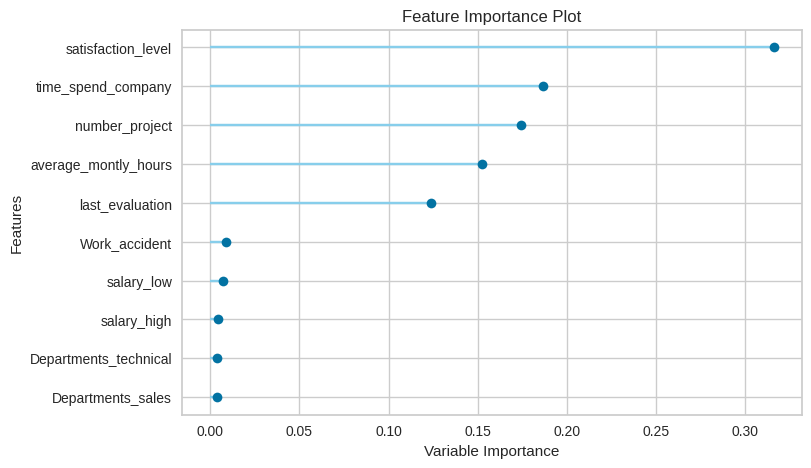

In [24]:
# Show the predictors
plot_model(rf_model, plot = 'feature')

# Create feature table

In [27]:
# Get feature name
rf_model.feature_names_in_

array(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident',
       'promotion_last_5years', 'Departments_management',
       'Departments_product_mng', 'Departments_sales', 'Departments_IT',
       'Departments_technical', 'Departments_RandD',
       'Departments_support', 'Departments_hr', 'Departments_marketing',
       'Departments_accounting', 'salary_medium', 'salary_low',
       'salary_high'], dtype=object)

In [28]:
# Get a feature importance score
rf_model.feature_importances_

array([0.31590926, 0.12397999, 0.17444144, 0.15228352, 0.18648895,
       0.00879937, 0.00166611, 0.00162452, 0.00118108, 0.00371594,
       0.00168   , 0.00380856, 0.00161397, 0.00297005, 0.00182668,
       0.00127811, 0.00163246, 0.00362204, 0.00697355, 0.0045044 ])

In [32]:
import pandas as pd
feature_table = pd.DataFrame(list(zip(rf_model.feature_names_in_ , rf_model.feature_importances_)),
                            columns = ['feature_name', "feature_importance"])
feature_table

,feature_name,feature_importance
0,satisfaction_level,0.315909
1,last_evaluation,0.123980
2,number_project,0.174441
3,average_montly_hours,0.152284
4,time_spend_company,0.186489
5,Work_accident,0.008799
6,promotion_last_5years,0.001666
7,Departments_management,0.001625
8,Departments_product_mng,0.001181
9,Departments_sales,0.003716


In [33]:
# Uplaod the feature table to the Google bigquery
feature_table.to_gbq('employee_churn.feature_table',
                     project_id=project_id,
                     chunksize=None,
                     if_exists='replace')

100%|██████████| 1/1 [00:00<00:00, 5584.96it/s]
